In [44]:
import numpy as np
import pandas as pd
import os
import random
import tensorflow as tf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

#Set random seed for reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional (recommended for TensorFlow >= 2.9)
tf.keras.utils.set_random_seed(SEED)

# Optional (TensorFlow >= 2.9)
tf.config.experimental.enable_op_determinism()

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score

# Save
import joblib

# Deep Learning
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint

import keras_tuner as kt


import warnings
warnings.filterwarnings("ignore")



In [3]:
# Load the dataset

df = pd.read_csv("Churn Modeling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# EDA and Preprocessing

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

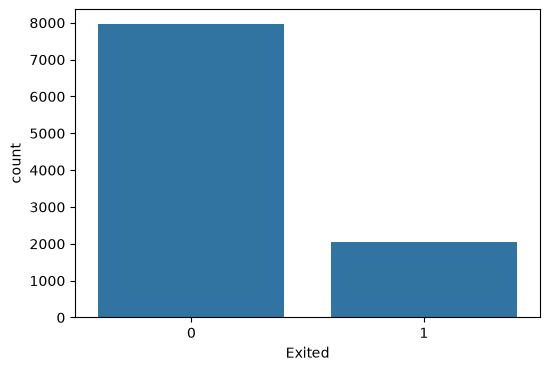

In [8]:
# Target Variable Distribution

plt.figure(figsize=(6,4))
sns.countplot(x=df["Exited"])
plt.show()

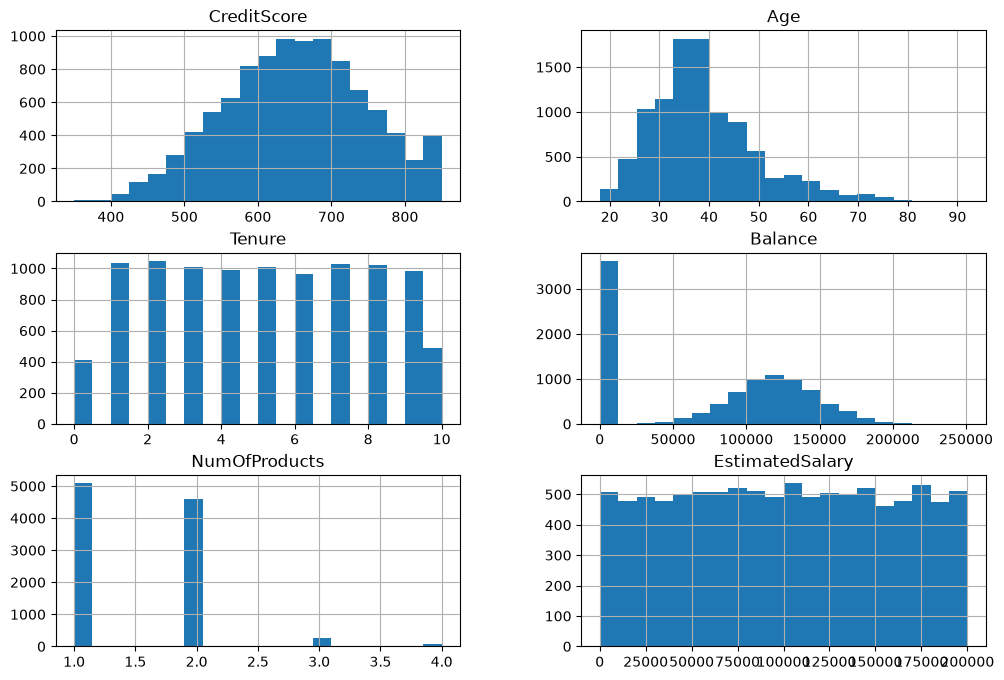

In [9]:
# Numerical Variables

num_df  = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
df[num_df].hist(bins=20, figsize=(12,8))
plt.show()

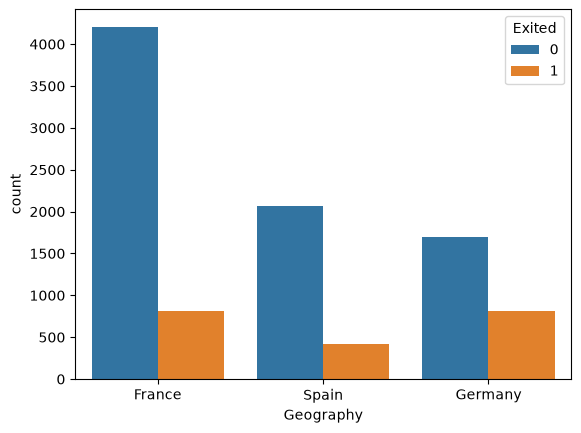

In [10]:
# Categorical Analysis

sns.countplot(x=df["Geography"],hue=df["Exited"])
plt.show()

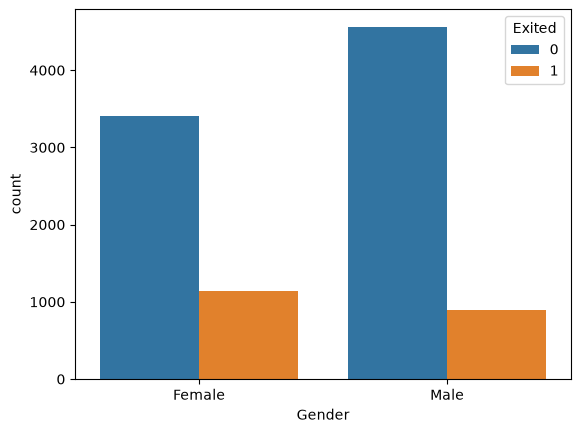

In [11]:
sns.countplot(x=df["Gender"], hue=df["Exited"])
plt.show()

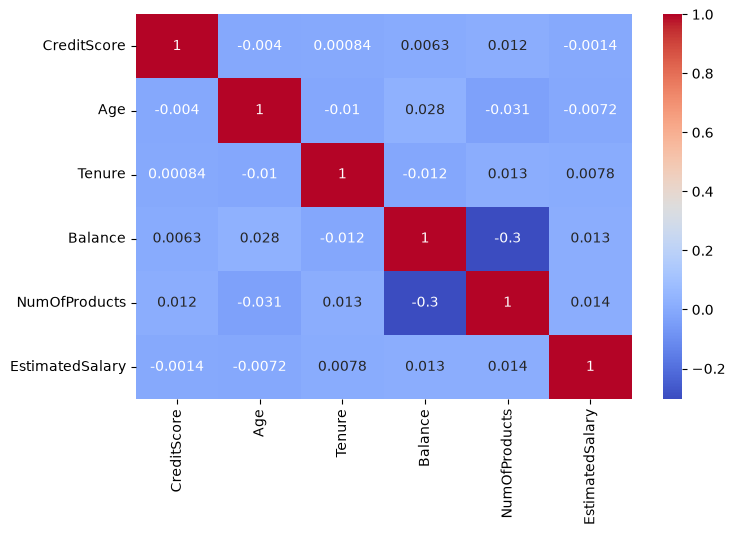

In [12]:
# Correlation Analysis

plt.figure(figsize=(8,5))
sns.heatmap(df[num_df].corr(), annot=True, cmap="coolwarm")
plt.show()

In [13]:
# Skewness and Transformation

df[num_df].skew()

CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
EstimatedSalary    0.002085
dtype: float64

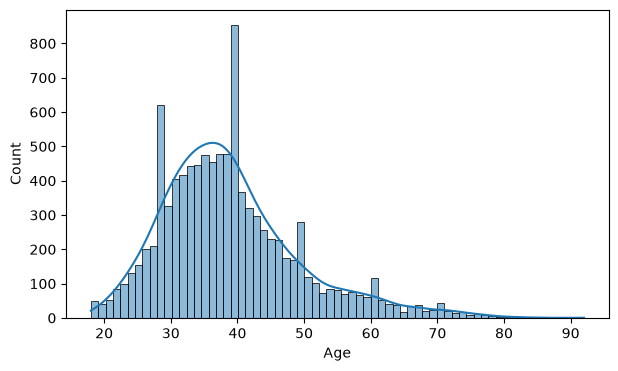

In [14]:
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], kde=True)
plt.show()

In [15]:
# Apply Power Transformation to reduce skewness
pt =PowerTransformer()
df["Age"] = pt.fit_transform(df[["Age"]])


In [16]:
# Save the fitted PowerTransformer

joblib.dump(pt, "power_transformer_age.pkl")

['power_transformer_age.pkl']

In [17]:
df["Age"].skew()

np.float64(-0.002495359883199229)

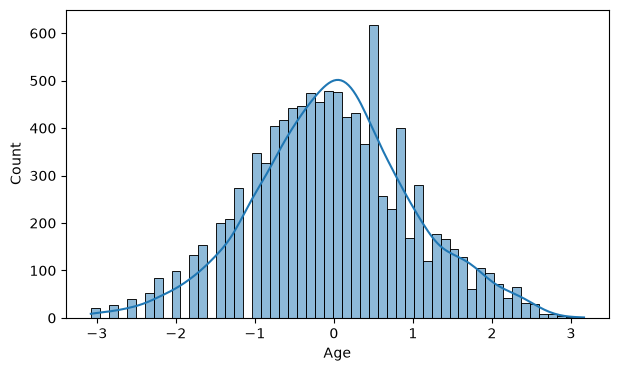

In [18]:
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], kde=True)
plt.show()

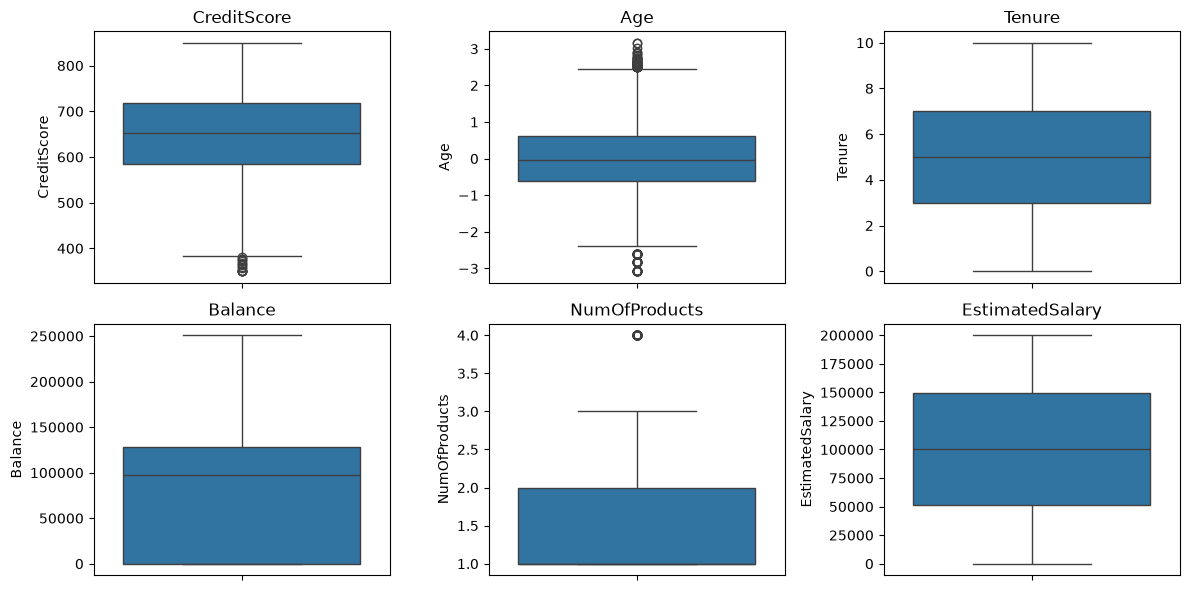

In [19]:
# Boxplot to check for outliers for numerical variables

plt.figure(figsize=(12,6))
for i, col in enumerate(num_df):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

In [20]:
# Create outlier treatment function

def treat_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

In [21]:
# Apply on required columns

outlier_cols = ["CreditScore", "Age", "EstimatedSalary"]

for col in outlier_cols:
    df = treat_outliers(df, col)

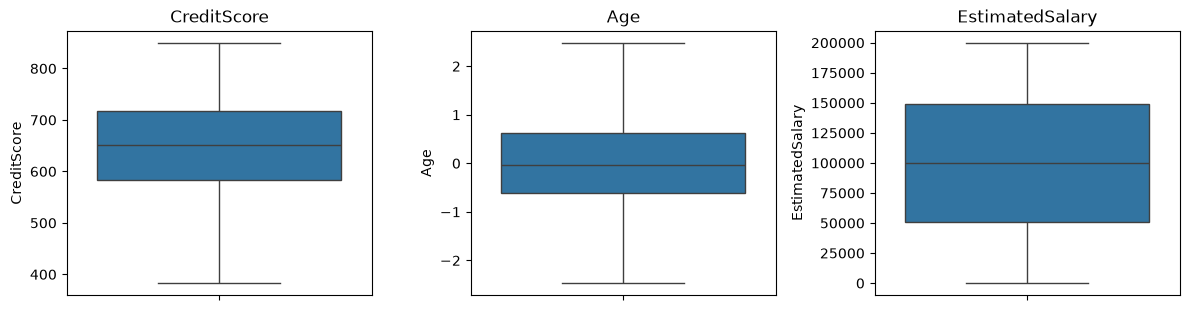

In [22]:
# Verify Again

plt.figure(figsize=(12,6))
for i, col in enumerate(outlier_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

In [23]:
# Feature Scaling

# Drop unnecessary columns

df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [24]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [25]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619.0,0.451286,2,0.00,1,1,1,101348.88,1,0,0,0
1,608.0,0.359732,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502.0,0.451286,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699.0,0.168117,1,0.00,2,0,0,93826.63,0,0,0,0
4,850.0,0.540200,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771.0,0.168117,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516.0,-0.253985,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709.0,-0.143111,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772.0,0.451286,3,75075.31,2,1,0,92888.52,1,1,0,1


In [26]:
# feature and target split
x = df.drop("Exited", axis=1)
y = df["Exited"]

In [27]:
# Save feature names

feature_names = x.columns.tolist()
joblib.dump(feature_names, "features_names.pkl")

['features_names.pkl']

In [28]:
# train-test split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42, stratify=y)

In [29]:
# Scaling

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [30]:
# Compare Models

models = {
    "Logistic Regression" : LogisticRegression(random_state=42),
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "Random Forest" : RandomForestClassifier(random_state=42),
    "KNN" : KNeighborsClassifier(),
    "SVM" : SVC(probability=True, random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
    "XGB Classifier" : XGBClassifier(random_state=42)
}

results = []

# Train

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # Probabilities for ROC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_prob = y_pred

    # Store the results
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

# Create Dataframe

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.8150     0.6294  0.2211    0.3273   0.7824
1        Decision Tree    0.7870     0.4786  0.5209    0.4988   0.6879
2        Random Forest    0.8620     0.7718  0.4570    0.5741   0.8502
3                  KNN    0.8255     0.6261  0.3538    0.4521   0.7564
4                  SVM    0.8615     0.8316  0.4005    0.5406   0.8221
5    Gradient Boosting    0.8685     0.7812  0.4914    0.6033   0.8711
6       XGB Classifier    0.8535     0.6926  0.5037    0.5832   0.8333


In [31]:
# Build ANN

ann = Sequential()

ann.add(Dense(128, activation="relu", input_shape=(x_train.shape[1],)))
ann.add(Dropout(0.3))
ann.add(Dense(64, activation ="relu"))
ann.add(Dropout(0.2))
ann.add(Dense(32, activation="relu"))
ann.add(Dense(1, activation="sigmoid"))

ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


In [32]:
# Early Stopping and Model Checkpoint

early = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_ann.keras", save_best_only = True, verbose=1)

In [33]:
# Train

history_ann = ann.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early, checkpoint]
)

Epoch 1/100
182/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7692 - loss: 0.4878
Epoch 1: val_loss improved from None to 0.42260, saving model to best_ann.keras

Epoch 1: finished saving model to best_ann.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7750 - loss: 0.4811 - val_accuracy: 0.8238 - val_loss: 0.4226
Epoch 2/100
198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8218 - loss: 0.4165
Epoch 2: val_loss improved from 0.42260 to 0.38391, saving model to best_ann.keras

Epoch 2: finished saving model to best_ann.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8228 - loss: 0.4150 - val_accuracy: 0.8487 - val_loss: 0.3839
Epoch 3/100
159/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8377 - loss: 0.3948
Epoch 3: val_loss improved from 0.38391 to 0.35548, saving model to best_ann.keras

Epoch 3: finished saving model to best_ann.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8373 - loss: 0.3930 - val_accuracy: 0.8606 - val_loss:

In [34]:
# ANN Evaluation

y_prob_ann = ann.predict(x_test)

y_pred_ann = (y_prob_ann > 0.5).astype(int)

# Evaluation Metrics
ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)
ann_roc = roc_auc_score(y_test, y_prob_ann)

# Print Results
print("ANN Model Performance")
print("-" * 30)
print(f"Accuracy: {round(ann_accuracy, 4)}")
print(f"Precision: {round(ann_precision, 4)}")
print(f"Recall   : {round(ann_recall, 4)}")
print(f"F1 Score : {round(ann_f1, 4)}")
print(f"ROC AUC  : {round(ann_roc, 4)}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_ann))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_ann))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
ANN Model Performance
------------------------------
Accuracy: 0.8625
Precision: 0.792
Recall   : 0.4398
F1 Score : 0.5656
ROC AUC  : 0.8561

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000


Confusion Matrix
[[1546   47]
 [ 228  179]]


In [35]:
# Hyperparameter Tuning

def build_model(hp):
    model = Sequential()
    # Input Layer

    model.add(Dense(hp.Int("unit0", 32, 256, step=32), 
                    activation=hp.Choice("activation", ["relu", "tanh"]), 
                    input_shape=(x_train.shape[1],)))
    
    # Hidden Layers
    for i in range(hp.Int("layers", 2,5)):
        model.add(Dense(hp.Int(f"unit{i}", 32, 256, step=32), activation=hp.Choice("activation", ["relu", "tanh"])))
        model.add(Dropout(0.2))

    # Output Layer
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer=hp.Choice("optimizer", ["adam", "rmsprop"]), loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [36]:
tuner = kt.RandomSearch(build_model, 
                        objective="val_accuracy", 
                        max_trials=10, 
                        overwrite=True, 
                        directory= "keras_tuner", 
                        project_name="bank_churn" )

tuner.search(x_train, y_train, epochs=20, validation_split=0.2)

Tuned_ANN = tuner.get_best_models(1)[0]



Trial 10 Complete [00h 00m 10s]
val_accuracy: 0.8725000023841858

Best val_accuracy So Far: 0.875
Total elapsed time: 00h 01m 44s


In [37]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hp.values

{'unit0': 32,
 'activation': 'tanh',
 'layers': 3,
 'unit1': 224,
 'optimizer': 'rmsprop',
 'unit2': 128,
 'unit3': 128,
 'unit4': 32}

In [38]:
# Retrain the best model

history_tuned = Tuned_ANN.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early, checkpoint]
)

Epoch 1/100
183/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8555 - loss: 0.3499
Epoch 1: val_loss did not improve from 0.33324
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.3485 - val_accuracy: 0.8756 - val_loss: 0.3392
Epoch 2/100
183/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8550 - loss: 0.3501
Epoch 2: val_loss did not improve from 0.33324
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8566 - loss: 0.3487 - val_accuracy: 0.8750 - val_loss: 0.3370
Epoch 3/100
176/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8601 - loss: 0.3477
Epoch 3: val_loss did not improve from 0.33324
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8612 - loss: 0.3457 - val_accuracy: 0.8756 - val_loss: 0.3372
Epoch 4/100
178/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8550 - loss: 0.3493
Epoch 4: val_loss did not improve from 0.33324
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8550 - loss: 0.3484 - val_accuracy: 0.8700 - val_loss: 0.3

In [39]:
# Evaluate the model

loss, accuracy = Tuned_ANN.evaluate(x_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8635 - loss: 0.3351
Test Loss: 0.33509278297424316
Test Accuracy: 0.8634999990463257


In [40]:
# Predictions

y_prob_tuned = Tuned_ANN.predict(x_test)
y_pred_tuned = (y_prob_tuned > 0.5).astype(int)

# Calculate Metrics for Tuned ANN
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned) 
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_roc = roc_auc_score(y_test, y_prob_tuned)

# Print Metrics for Tuned ANN
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)
print("ROC AUC  :", tuned_roc)

print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Accuracy : 0.8635
Precision: 0.7913043478260869
Recall   : 0.44717444717444715
F1 Score : 0.5714285714285714
ROC AUC  : 0.86739744366863
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000

[[1545   48]
 [ 225  182]]


In [41]:
# Now compare the Tuned_ANN with the previous ANN and other models using the same evaluation metrics.

final_results = results_df.copy()


final_results.loc[len(final_results)] = {
    "Model": "ANN",
    "Accuracy": round(ann_accuracy, 4),
    "Precision": round(ann_precision, 4),
    "Recall": round(ann_recall, 4),
    "F1 Score": round(ann_f1, 4),
    "ROC AUC": round(ann_roc, 4)
}

final_results.loc[len(final_results)] = {
    "Model": "Tuned ANN",
    "Accuracy": round(tuned_accuracy, 4),
    "Precision": round(tuned_precision, 4),
    "Recall": round(tuned_recall, 4),
    "F1 Score": round(tuned_f1, 4),
    "ROC AUC": round(tuned_roc, 4)
}

final_results = final_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print(final_results)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0    Gradient Boosting    0.8685     0.7812  0.4914    0.6033   0.8711
1            Tuned ANN    0.8635     0.7913  0.4472    0.5714   0.8674
2                  ANN    0.8625     0.7920  0.4398    0.5656   0.8561
3        Random Forest    0.8620     0.7718  0.4570    0.5741   0.8502
4                  SVM    0.8615     0.8316  0.4005    0.5406   0.8221
5       XGB Classifier    0.8535     0.6926  0.5037    0.5832   0.8333
6                  KNN    0.8255     0.6261  0.3538    0.4521   0.7564
7  Logistic Regression    0.8150     0.6294  0.2211    0.3273   0.7824
8        Decision Tree    0.7870     0.4786  0.5209    0.4988   0.6879


In [42]:
# Train the final Gradient Boosting model

best_model = GradientBoostingClassifier(random_state=42)
best_model.fit(x_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [43]:
# Save the model

joblib.dump(best_model, "gradient_boosting_model.pkl")

['gradient_boosting_model.pkl']